In [1]:
import kagglehub
path = kagglehub.dataset_download("debajyotipodder/co2-emission-by-vehicles")

Using Colab cache for faster access to the 'co2-emission-by-vehicles' dataset.


In [12]:
path

'/kaggle/input/co2-emission-by-vehicles'

In [21]:
import numpy as np
import pandas as pd
from sklearn import linear_model

In [15]:
df  = pd.read_csv(path + '/CO2 Emissions_Canada.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [16]:
df_refined = df.drop(columns = ['Make','Model','Vehicle Class','Transmission','Fuel Type'])
df_refined.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


In [17]:
df_refined.isnull().sum()

,0
Engine Size(L),0
Cylinders,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0
Fuel Consumption Comb (mpg),0
CO2 Emissions(g/km),0


In [18]:
df_refined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Engine Size(L)                    7385 non-null   float64
 1   Cylinders                         7385 non-null   int64  
 2   Fuel Consumption City (L/100 km)  7385 non-null   float64
 3   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 4   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 5   Fuel Consumption Comb (mpg)       7385 non-null   int64  
 6   CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 404.0 KB


In [22]:
#Luckily this dataset doesn't have null values
## Let's start training linear model on input features

## Input features are
### Engine Size (L)
### Cylinders
### Fuel Consumption City (L/100 km)
###  Fuel Consumption Hwy (L/100 km)
###  Fuel Consumption Comb (L/100 km)
###  Fuel Consumption Comb (mpg)

## Out of the model is
###   CO2 Emissions(g/km)

In [26]:
lr = linear_model.LinearRegression()
lr.fit(df_refined[['Engine Size(L)','Cylinders','Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (L/100 km)','Fuel Consumption Comb (mpg)']], df_refined['CO2 Emissions(g/km)'])


LinearRegression()

In [27]:
#Now let's explore the model parameters

In [29]:
# coefficients of model linear curve
# one coefficient for each column (feature) of the model
lr.coef_

array([ 4.9936038 ,  7.53852995, -0.02378355,  4.49061364,  1.67304643,
       -3.42349241])

In [30]:
# intercept of the linear line
lr.intercept_

np.float64(227.89275084614138)

In [31]:
# re-creating model equation using coefficients and intercept
y = lr.coef_[0]*df_refined['Engine Size(L)'] + lr.coef_[1]*df_refined['Cylinders'] + lr.coef_[2]*df_refined['Fuel Consumption City (L/100 km)'] + lr.coef_[3]*df_refined['Fuel Consumption Hwy (L/100 km)'] + lr.coef_[4]*df_refined['Fuel Consumption Comb (L/100 km)'] + lr.coef_[5]*df_refined['Fuel Consumption Comb (mpg)'] + lr.intercept_

In [35]:
# predicting output based on Linear Regression Model
y1 = lr.predict(df_refined[['Engine Size(L)','Cylinders','Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (L/100 km)','Fuel Consumption Comb (mpg)']])

In [ ]:
#let's plot the comparison of equation and linear regression model of SKLearn


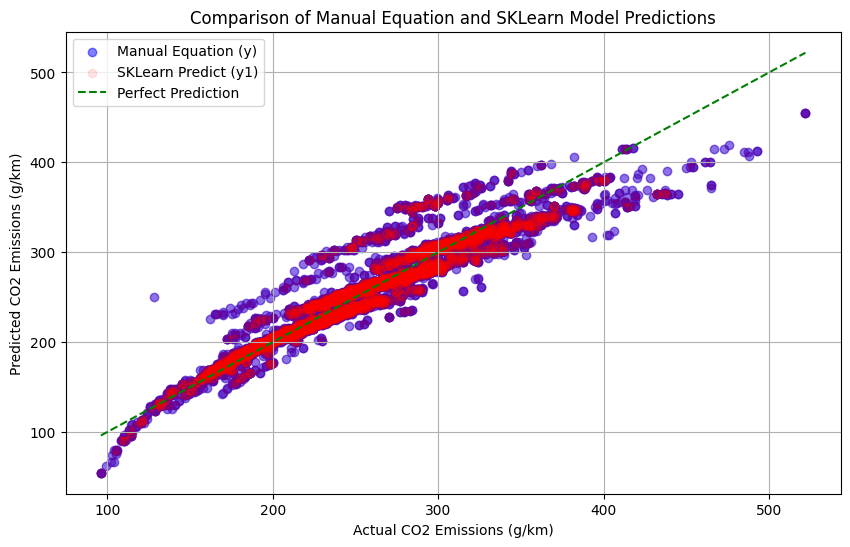

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_refined['CO2 Emissions(g/km)'], y, color='blue', label='Manual Equation (y)', alpha=0.5)
plt.scatter(df_refined['CO2 Emissions(g/km)'], y1, color='red', label='SKLearn Predict (y1)', alpha=0.1)
plt.plot([df_refined['CO2 Emissions(g/km)'].min(), df_refined['CO2 Emissions(g/km)'].max()],
         [df_refined['CO2 Emissions(g/km)'].min(), df_refined['CO2 Emissions(g/km)'].max()],
         color='green', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual CO2 Emissions (g/km)')
plt.ylabel('Predicted CO2 Emissions (g/km)')
plt.title('Comparison of Manual Equation and SKLearn Model Predictions')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation Metrics

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

print('----------- Model based --------------')
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(df_refined['CO2 Emissions(g/km)'], y1)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate R-squared (R2) score
r2 = r2_score(df_refined['CO2 Emissions(g/km)'], y1)
print(f"R-squared (R2) Score: {r2:.2f}")

print('----------- Equation based --------------')
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(df_refined['CO2 Emissions(g/km)'], y)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate R-squared (R2) score
r2 = r2_score(df_refined['CO2 Emissions(g/km)'], y)
print(f"R-squared (R2) Score: {r2:.2f}")

----------- Model based --------------
Mean Squared Error (MSE): 328.95
R-squared (R2) Score: 0.90
----------- Equation based --------------
Mean Squared Error (MSE): 328.95
R-squared (R2) Score: 0.90


In [55]:
df_high_emission = df_refined[df_refined['CO2 Emissions(g/km)'] > 400]
display(df_high_emission.head())
# Let's separate high emission cars from the main data set

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
46,4.2,8,21.2,13.4,17.7,16,407
48,5.2,10,21.1,13.8,17.8,16,409
50,4.2,8,21.2,13.4,17.7,16,407
52,5.2,10,21.1,13.8,17.8,16,409
75,6.8,8,22.3,14.9,19.0,15,437


In [45]:
df_high_emission.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,5.948980,9.387755,22.713265,15.169388,19.315306,14.826531,432.112245
std,0.863969,2.213514,2.876769,2.035226,2.316608,1.506176,28.641720
min,3.500000,6.000000,18.200000,12.700000,17.100000,11.000000,401.000000
25%,5.500000,8.000000,20.900000,13.800000,17.900000,14.000000,413.000000
50%,6.000000,8.000000,22.000000,14.900000,18.650000,15.000000,420.500000
75%,6.500000,12.000000,23.750000,15.875000,19.700000,16.000000,444.000000
max,8.000000,16.000000,30.600000,20.600000,26.100000,17.000000,522.000000


In [56]:
# From graph it's evident that emission predicted above 400 range are away from
# ideal line, let's test them with both i.e. equation and linear reg model
#output_model = lr.predict([[3.5,	6,	12.1,	8.7,	10.6,	27]])	#predicting for 200
output_model = lr.predict([[5.2,10,21.1,13.8,17.8,16]])
output_model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([365.71777326])

In [58]:
# re-creating model equation using coefficients and intercept
output_equation = lr.coef_[0]*5.2 + lr.coef_[1]*10 + lr.coef_[2]*21.1 + lr.coef_[3]*13.8 + lr.coef_[4]*17.8 + lr.coef_[5]*16 + lr.intercept_
output_equation

np.float64(365.7177732559021)

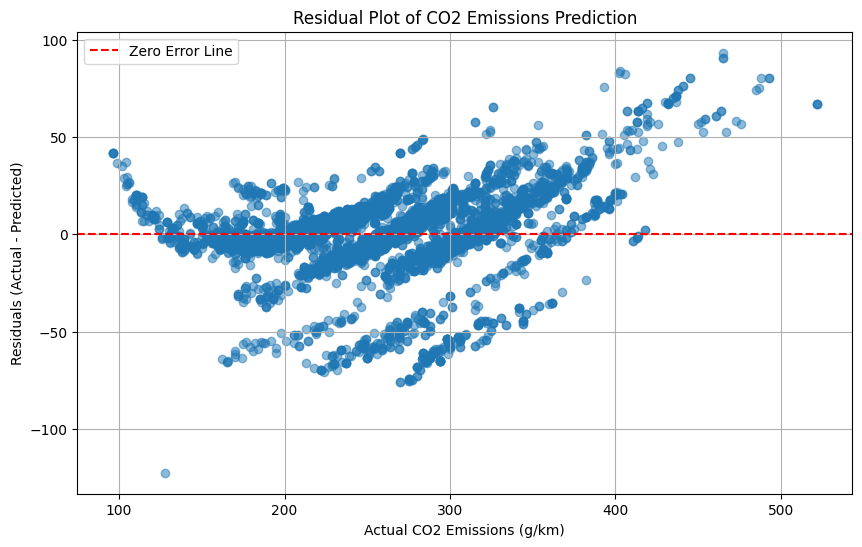

In [59]:
# Calculate the residuals (error)
residuals = df_refined['CO2 Emissions(g/km)'] - y1

plt.figure(figsize=(10, 6))
plt.scatter(df_refined['CO2 Emissions(g/km)'], residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error Line')
plt.xlabel('Actual CO2 Emissions (g/km)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot of CO2 Emissions Prediction')
plt.legend()
plt.grid(True)
plt.show()

The residual plot shows the difference between the actual and predicted values. Ideally, residuals should be randomly scattered around zero, indicating that the model captures the underlying pattern well and there's no systematic error. Any patterns in this plot (e.g., a funnel shape or a curve) could suggest that the model might not be the best fit for the data or that some assumptions of linear regression are violated.